<a href="https://colab.research.google.com/github/BilalKhaliqWillis/BILAL-Assignment2/blob/main/BILAL_Assignment_9_Time_Series_Analysis_with_AutoReg_and_ARMA_Models_in_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Uploading the Dataset
from google.colab import files
uploaded = files.upload()

Saving electricity_consumption.csv to electricity_consumption.csv


In [2]:
# Importing the Required Libraries
# Basic libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Time series tools
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.ar_model import AutoReg, ar_select_order
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ARMA / ARIMA model
from statsmodels.tsa.arima.model import ARIMA

import warnings
warnings.filterwarnings('ignore')

In [3]:
# Loading the Dataset
df = pd.read_csv("electricity_consumption.csv")

# Converting the datetime column
df['datetime'] = pd.to_datetime(df['datetime'])

# Setting the datetime as index
df.set_index('datetime', inplace=True)

# Viewing the first few rows
df.head()

,electricity_consumption
datetime,
2020-01-01 00:00:00,52.483571
2020-01-01 01:00:00,51.899723
2020-01-01 02:00:00,58.244150
2020-01-01 03:00:00,64.694779
2020-01-01 04:00:00,57.500903


In [4]:
# Converting the Hourly Data to Monthly Data
# Seasonal period in assignment = 12 months.
# Converting the hourly data to monthly average
monthly_data = df.resample('M').mean()

monthly_data.head()

,electricity_consumption
datetime,
2020-01-31,50.988843
2020-02-29,53.603489
2020-03-31,55.320921
2020-04-30,57.336798
2020-05-31,59.350803


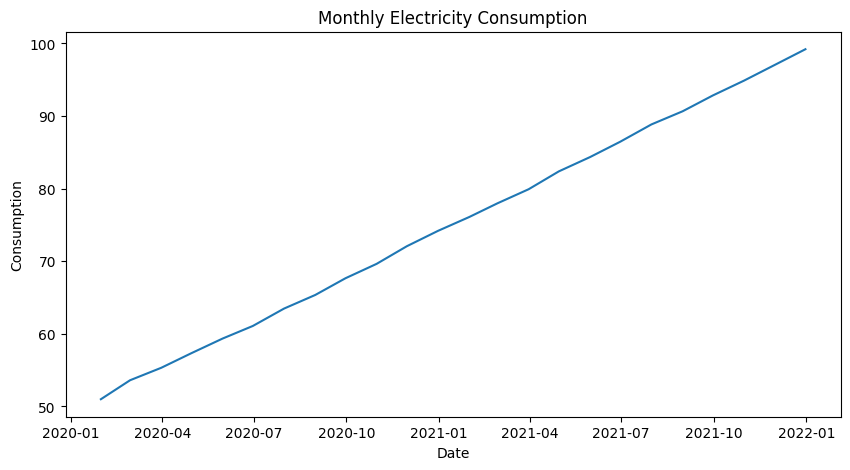

'The plot identifies trends and seasonality.'

In [5]:
# Plotting the Time Series
plt.figure(figsize=(10,5))
plt.plot(monthly_data)
plt.title("Monthly Electricity Consumption")
plt.xlabel("Date")
plt.ylabel("Consumption")
plt.show()

"""The plot identifies trends and seasonality."""

In [6]:
# Augmented Dickey Fuller (ADF) Test
# ADF Test
result = adfuller(monthly_data['electricity_consumption'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

if result[1] < 0.05:
    print("Series is Stationary")
else:
    print("Series is NOT Stationary")

ADF Statistic: 0.9694096139851394
p-value: 0.9939324653544185
Series is NOT Stationary


In [7]:
# Apply Differencing
# First differencing
diff1 = monthly_data.diff().dropna()

# Seasonal differencing (period = 12)
seasonal_diff = diff1.diff(12).dropna()

seasonal_diff.head()

,electricity_consumption
datetime,
2021-02-28,-0.728902
2021-03-31,0.222920
2021-04-30,0.444036
2021-05-31,-0.043768
2021-06-30,0.381471


In [8]:
# Recheck Stationarity
result = adfuller(seasonal_diff['electricity_consumption'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

if result[1] < 0.05:
    print("Series is now Stationary")
else:
    print("Still NOT Stationary")

ADF Statistic: -2.3733504241827634
p-value: 0.14939973924079353
Still NOT Stationary


In [14]:
# Safe lag selection for small dataset
max_lag = 2

sel = ar_select_order(
    seasonal_diff['electricity_consumption'],
    maxlag=max_lag,
    ic='aic'
)

print("Optimal Lags:", sel.ar_lags)

Optimal Lags: None


In [15]:
model_ar = AutoReg(
    seasonal_diff['electricity_consumption'],
    lags=sel.ar_lags
)

model_ar_fit = model_ar.fit()

print(model_ar_fit.summary())

                               AutoReg Model Results                               
Dep. Variable:     electricity_consumption   No. Observations:                   11
Model:                          AutoReg(0)   Log Likelihood                  -2.662
Method:                    Conditional MLE   S.D. of innovations              0.308
Date:                     Sun, 08 Mar 2026   AIC                              9.324
Time:                             22:10:02   BIC                             10.120
Sample:                         02-28-2021   HQIC                             8.822
                              - 12-31-2021                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0077      0.093     -0.082      0.934      -0.190       0.174


In [16]:
# Fitting the AutoReg Model
model_ar = AutoReg(seasonal_diff['electricity_consumption'], lags=sel.ar_lags)

model_ar_fit = model_ar.fit()

print(model_ar_fit.summary())

                               AutoReg Model Results                               
Dep. Variable:     electricity_consumption   No. Observations:                   11
Model:                          AutoReg(0)   Log Likelihood                  -2.662
Method:                    Conditional MLE   S.D. of innovations              0.308
Date:                     Sun, 08 Mar 2026   AIC                              9.324
Time:                             22:10:09   BIC                             10.120
Sample:                         02-28-2021   HQIC                             8.822
                              - 12-31-2021                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0077      0.093     -0.082      0.934      -0.190       0.174


In [17]:
# Creating the Exogenous Variable -Month
# Create month variable
seasonal_diff['month'] = seasonal_diff.index.month

# Converting to dummy variables
month_dummies = pd.get_dummies(seasonal_diff['month'], drop_first=True)

month_dummies.head()

,3,4,5,6,7,8,9,10,11,12
datetime,,,,,,,,,,
2021-02-28,False,False,False,False,False,False,False,False,False,False
2021-03-31,True,False,False,False,False,False,False,False,False,False
2021-04-30,False,True,False,False,False,False,False,False,False,False
2021-05-31,False,False,True,False,False,False,False,False,False,False
2021-06-30,False,False,False,True,False,False,False,False,False,False


In [21]:
# Creating exogenous variable (month number)
seasonal_diff['month'] = seasonal_diff.index.month

# Using the month as numeric variable
exog = seasonal_diff[['month']]

exog.head()

,month
datetime,
2021-02-28,2
2021-03-31,3
2021-04-30,4
2021-05-31,5
2021-06-30,6


In [25]:
# AutoReg model with exogenous variable -month

model_exog = AutoReg(
    seasonal_diff['electricity_consumption'],
    lags=2,
    exog=exog
)

model_exog_fit = model_exog.fit()

print(model_exog_fit.summary())

print("AutoReg AIC:", model_ar_fit.aic)
print("AutoReg + Exog AIC:", model_exog_fit.aic)

print("AutoReg BIC:", model_ar_fit.bic)
print("AutoReg + Exog BIC:", model_exog_fit.bic)

                               AutoReg Model Results                               
Dep. Variable:     electricity_consumption   No. Observations:                   11
Model:                        AutoReg-X(2)   Log Likelihood                   7.792
Method:                    Conditional MLE   S.D. of innovations              0.102
Date:                     Sun, 08 Mar 2026   AIC                             -5.585
Time:                             22:13:36   BIC                             -4.599
Sample:                         04-30-2021   HQIC                            -7.713
                              - 12-31-2021                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                          0.9622      0.166      5.788      0.000       0.636       1.288
electricity_consumption.L1    -0.9324      

In [27]:
# Forecasting the next 24 months
forecast_steps = 24

# Creating the future month values
last_date = seasonal_diff.index[-1]

future_dates = pd.date_range(
    start=last_date + pd.offsets.MonthEnd(1),
    periods=forecast_steps,
    freq='M'
)

# Creating exogenous variable for future months
future_month = pd.DataFrame({
    'month': future_dates.month
})

# Forecasting
forecast = model_exog_fit.predict(
    start=len(seasonal_diff),
    end=len(seasonal_diff) + forecast_steps - 1,
    exog_oos=future_month
)

forecast

,0
2022-01-31,0.829927
2022-02-28,-0.038236
2022-03-31,0.542416
2022-04-30,0.035488
2022-05-31,0.306883
2022-06-30,0.029530
2022-07-31,0.137188
2022-08-31,-0.024851
2022-09-30,0.001931
2022-10-31,-0.103462


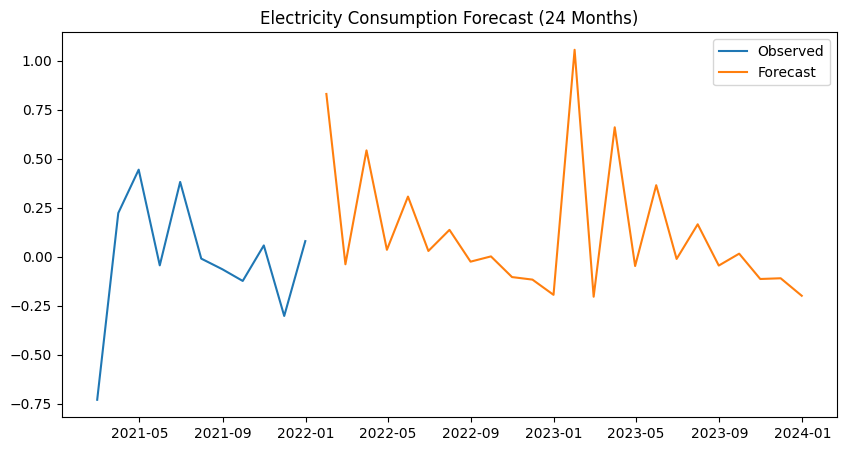

In [30]:
# Plotting the Forecasts
plt.figure(figsize=(10,5))

plt.plot(seasonal_diff.index,
         seasonal_diff['electricity_consumption'],
         label="Observed")

plt.plot(future_dates,
         forecast,
         label="Forecast")

plt.title("Electricity Consumption Forecast (24 Months)")
plt.legend()

plt.show()

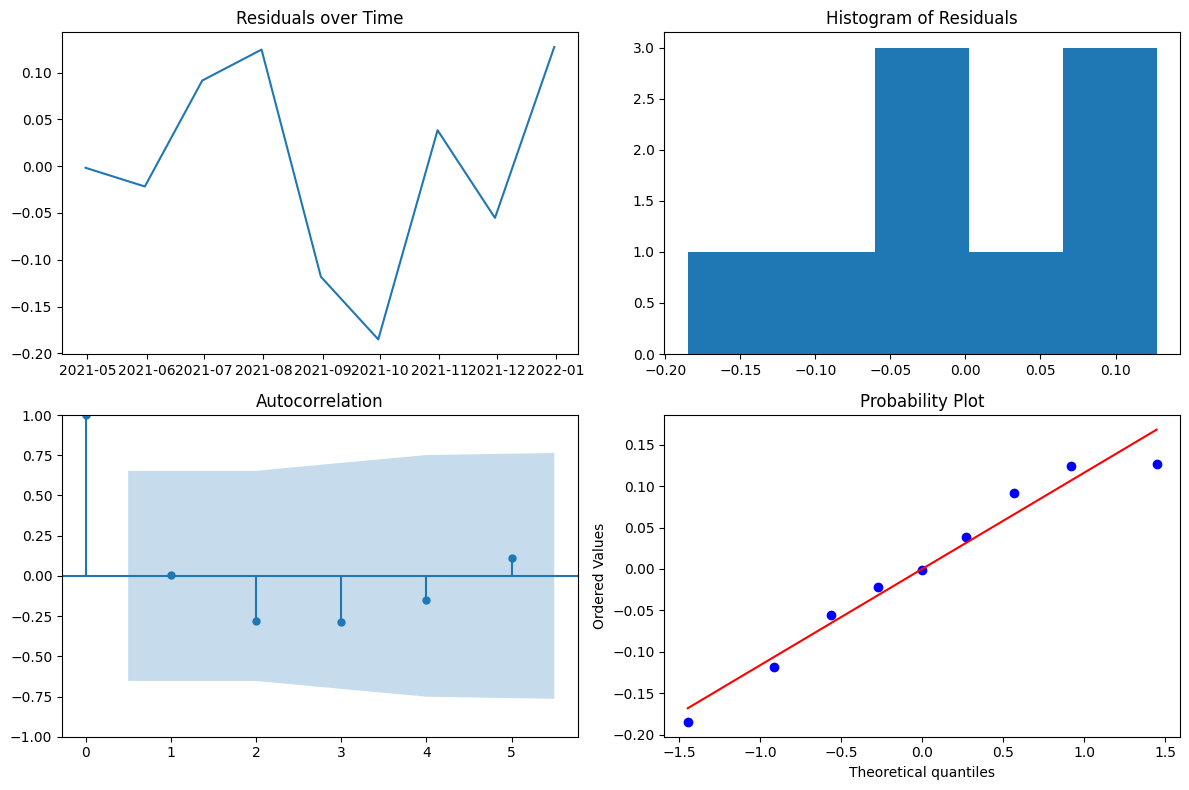

In [32]:
# Model Diagnostics
residuals = model_exog_fit.resid

plt.figure(figsize=(12,8))

# Residuals over time
plt.subplot(221)
plt.plot(residuals)
plt.title("Residuals over Time")

# Histogram
plt.subplot(222)
plt.hist(residuals, bins=5)
plt.title("Histogram of Residuals")

# ACF of residuals
from statsmodels.graphics.tsaplots import plot_acf
plt.subplot(223)
plot_acf(residuals, lags=5, ax=plt.gca())

# Q-Q plot
import scipy.stats as stats
plt.subplot(224)
stats.probplot(residuals, dist="norm", plot=plt)

plt.tight_layout()
plt.show()

ValueError: could not broadcast input array from shape (11,) into shape (25,)

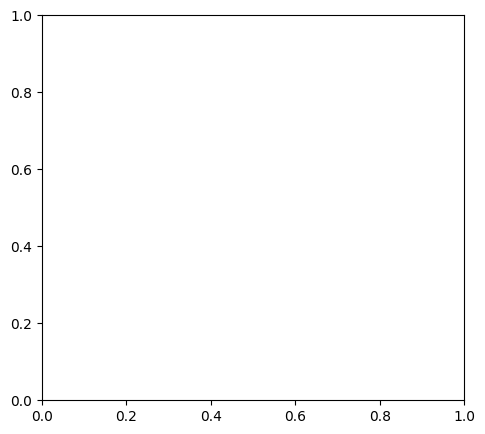

In [34]:
# ACF and PACF
# Used to identify ARMA parameters
plt.figure(figsize=(12,5))

plt.subplot(121)
plot_acf(seasonal_diff['electricity_consumption'], lags=24, ax=plt.gca())

plt.subplot(122)
plot_pacf(seasonal_diff['electricity_consumption'], lags=24, ax=plt.gca())

plt.show()

"""Typical interpretation:

PACF spike → AR terms

ACF spike → MA terms

Possible values: - P = 1 - Q = 1"""

In [35]:
# Fitting ARMA Model
# ARMA(p,q) = ARIMA(p,0,q)
arma_model = ARIMA(
    seasonal_diff['electricity_consumption'],
    order=(1,0,1)
)

arma_fit = arma_model.fit()

print(arma_fit.summary())

                                  SARIMAX Results                                  
Dep. Variable:     electricity_consumption   No. Observations:                   11
Model:                      ARIMA(1, 0, 1)   Log Likelihood                  -1.629
Date:                     Sun, 08 Mar 2026   AIC                             11.258
Time:                             22:27:27   BIC                             12.849
Sample:                         02-28-2021   HQIC                            10.254
                              - 12-31-2021                                         
Covariance Type:                       opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0217      0.076      0.286      0.775      -0.127       0.170
ar.L1          0.4616      0.975      0.473      0.636      -1.449       2.373
ma.L1       

In [36]:
# Comparing the Models
print("AutoReg AIC:", model_exog_fit.aic)
print("ARMA AIC:", arma_fit.aic)

print("AutoReg BIC:", model_exog_fit.bic)
print("ARMA BIC:", arma_fit.bic)

"""Lower AIC/BIC into better model."""

AutoReg AIC: -5.584632392887023
ARMA AIC: 11.257641272771673
AutoReg BIC: -4.598509506205925
ARMA BIC: 12.849222363965156


'Lower AIC/BIC into better model.'

In [37]:
# ARMA Forecast
arma_forecast = arma_fit.forecast(steps=24)

arma_forecast

,predicted_mean
2022-01-31,0.101467
2022-02-28,0.058525
2022-03-31,0.038704
2022-04-30,0.029555
2022-05-31,0.025332
2022-06-30,0.023383
2022-07-31,0.022483
2022-08-31,0.022068
2022-09-30,0.021876
2022-10-31,0.021788


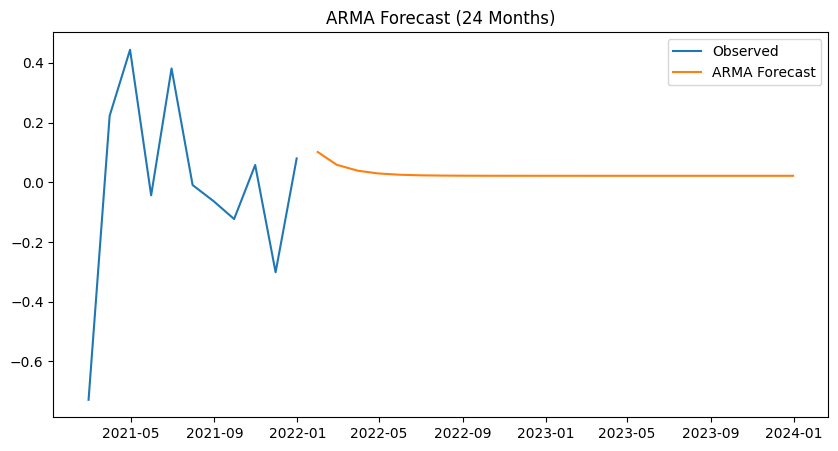

In [38]:
# Plotting the ARMA Forecast
plt.figure(figsize=(10,5))

plt.plot(seasonal_diff['electricity_consumption'], label="Observed")

forecast_index = pd.date_range(
    start=seasonal_diff.index[-1],
    periods=25,
    freq='M'
)[1:]

plt.plot(forecast_index, arma_forecast, label="ARMA Forecast")

plt.title("ARMA Forecast (24 Months)")
plt.legend()

plt.show()